## Spectra generation


In [1]:
import multirex as mrex
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.exceptions import DataConversionWarning
import os
import re
import gc
import warnings
import joblib
import ast

import tensorflow as tf
from tensorflow import keras

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import  ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

def remove_warnings():
    warnings.filterwarnings("ignore", category=DeprecationWarning)
    warnings.filterwarnings(action='ignore', category=DataConversionWarning)
    warnings.filterwarnings(
        "ignore",
        category=UserWarning,
        message="Pandas doesn't allow columns to be created via a new attribute name*",
    )


def configure_gpu_memory_growth():
    """Prevents TensorFlow from allocating all GPU memory at once."""
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            print(f"TensorFlow memory growth set for {len(gpus)} GPU(s).")
        except RuntimeError as e:
            print(f"GPU memory growth could not be set: {e}")


remove_warnings()
configure_gpu_memory_growth()
waves=np.loadtxt("waves.txt")
n_points = len(waves)
mix_ratios = np.logspace(-8, -1, 8)

Numba not installed, using numpy instead
Loading MultiREx version 0.3.2


2025-08-12 17:27:59.740643: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-12 17:27:59.753025: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755008879.765834   42323 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755008879.769884   42323 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755008879.780762   42323 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

TensorFlow memory growth set for 1 GPU(s).


## Helper Functions


In [2]:
def apply_contaminations_from_files(contamination_files, df, n_points):
    """
    Applies multiple contaminations to the data from a list of contamination files
    and returns a DataFrame with all combinations, including the non-contaminated case.

    Parameters:
        contamination_files (list of str): Paths to .txt files containing contaminations.
        df (pandas.DataFrame): Original DataFrame to apply contaminations.
        n_points (int): Number of columns to which the contamination will be applied.

    Returns:
        pandas.DataFrame: DataFrame with all combinations of contaminations, including the
        non-contaminated case, with additional columns 'f_spot' and 'f_fac'.
    """
    df_list = []

    # Non-contaminated case: create a copy and add f_spot and f_fac as 0.0
    df_no_contam = df.copy().assign(f_spot=0.0, f_fac=0.0)
    # Reorder columns to place 'f_spot' and 'f_fac' at the beginning
    cols = ["f_spot", "f_fac"] + [col for col in df.columns if col not in ["f_spot", "f_fac"]]
    df_list.append(df_no_contam[cols])

    # Regular expression to extract f_spot and f_fac from the file name.
    # Expected pattern: fspot<value>_ffac<value>.txt
    pattern = r"fspot(?P<f_spot>[0-9.]+)_ffac(?P<f_fac>[0-9.]+)\.txt$"

    for file_path in contamination_files:
        # Verify that the file exists
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"The file {file_path} does not exist.")

        # Extract the file name and use the regex pattern to get f_spot and f_fac values
        filename = os.path.basename(file_path)
        match = re.search(pattern, filename)
        if not match:
            raise ValueError(f"The file name '{filename}' does not match the expected pattern.")

        f_spot = float(match.group("f_spot"))
        f_fac = float(match.group("f_fac"))

        # Read contamination data from the file, ensuring it has at least 2 dimensions
        try:
            contamination_data = np.loadtxt(file_path, ndmin=2)
            # If there are at least two columns, take the second one; otherwise, flatten the array
            contam_values = contamination_data[:, 1] if contamination_data.shape[1] >= 2 else contamination_data.flatten()
            # Check that the number of contamination values matches the expected n_points
            if len(contam_values) != n_points:
                raise ValueError(
                    f"The number of contamination values in '{filename}' ({len(contam_values)}) "
                    f"does not match n_points ({n_points})."
                )
        except Exception as e:
            raise ValueError(f"Error reading the file {file_path}: {e}")

    
        # Reverse the contamination values if needed (e.g., to match column order)
        contam_values = contam_values[::-1]

        # Create a copy of the original DataFrame for contamination application
        df_contam = df.copy()
        # Multiply the last n_points columns by the contamination values
        data_columns = df_contam.columns[-n_points:]
        df_contam[data_columns] = df_contam[data_columns].multiply(contam_values, axis=1)

        # Add the contamination parameters as new columns
        df_contam["f_spot"] = f_spot
        df_contam["f_fac"] = f_fac
        # Reorder columns to place the new parameters at the beginning
        cols = ["f_spot", "f_fac"] + [col for col in df_contam.columns if col not in ["f_spot", "f_fac"]]
        df_contam = df_contam[cols]
        df_list.append(df_contam)

    # Concatenate all DataFrames into one final DataFrame
    df_final = pd.concat(df_list, ignore_index=True).copy()
    # Define .data and .params attributes for later use
    df_final.data = df_final.iloc[:, -n_points:]
    df_final.params = df_final.iloc[:, :-n_points]

    return df_final


def filter_rows(df):
    """
    Filters rows of a DataFrame where at least one of the columns
    "atm CH4", "atm O3", or "atm H2O" has a value >= -8.
    Returns the DataFrame unchanged if none of these columns are present.
    """
    filter_columns = ["atm CH4", "atm O3", "atm H2O"]
    present_columns = [col for col in filter_columns if col in df.columns]

    for chem in present_columns:
        df = df[df[chem] >= -8]
        # Set .data and .params attributes on the final DataFrame
    df.data = df.iloc[:, -n_points:]
    df.params = df.iloc[:, :-n_points]
    return df

def load_and_prep_data(filepath, n_points):
    """Reads a CSV and converts only the spectral data columns to float32."""
    df = pd.read_csv(filepath)
    # Identify spectral data columns (last n_points)
    data_cols = df.columns[-n_points:]
    # Convert only spectral data to float32, leave params as they are
    df[data_cols] = df[data_cols].astype("float32")
    return df

# Función para normalizar por filas con Min-Max, con manejo de casos especiales
def normalize_min_max_by_row(df):
    min_by_row = df.min(axis=1)
    max_by_row = df.max(axis=1)
    range_by_row = max_by_row - min_by_row
    # Avoid division by zero
    range_by_row[range_by_row == 0] = 1
    normalized = (df.sub(min_by_row, axis=0)).div(range_by_row, axis=0)
    return normalized

def generate_df_with_noise_std(df, n_repeat, noise_std, seed=None):
    # Checking 'params' and 'data' attributes in the DataFrame
    if not hasattr(df, "params"):
        print("Warning: The 'params' attribute was not found in the DataFrame.")
        df_params = pd.DataFrame()
        if not hasattr(df, "data"):
            print("Warning: The 'data' attribute was not found in the DataFrame.",
                  "The DataFrame will be considered to contain only spectral data.")
            df_spectra = df
    else:
        if not hasattr(df, "data"):
            raise ValueError("The DataFrame must have a 'data' attribute.")
        else:
            df_params = df.params
            df_spectra = df.data
            

    df_spectra = df_spectra.astype("float32")
    
    '''
    # Validaciones de tipos y valores de los parámetros
    if not isinstance(df_spectra, pd.DataFrame):
        raise ValueError("df_spectra debe ser un pandas DataFrame.")
    if not isinstance(df_params, pd.DataFrame):
        raise ValueError("df_params debe ser un pandas DataFrame.")
    if (not isinstance(n_repeat, int) or n_repeat <= 0):
        raise ValueError("n_repeat debe ser un entero positivo.")
    if isinstance(noise_std, (int, float)):
        if noise_std < 0:
            raise ValueError("noise_std debe ser un número positivo.")
    elif isinstance(noise_std, (list, np.ndarray, pd.Series)):
        if not all(n > 0 for n in noise_std):
            raise ValueError("Todos los valores en noise_std deben ser positivos.")
        if len(noise_std) != len(df_spectra):
            raise ValueError("La longitud de noise_std debe coincidir con el número de espectros en df.")
    else:
        raise ValueError("noise_std debe ser un número positivo o una lista/array de números positivos.")
    if (seed is not None and
        (not isinstance(seed, int) or seed < 0)):
        raise ValueError("seed debe ser un entero no negativo.")
    '''

    # Seed setup for reproducibility
    if seed is not None:
        np.random.seed(seed)  

    # Replication of the Spectra DataFrame according to the repetition factor
    df_spectra_replicated = pd.DataFrame(
        np.repeat(df_spectra.values, n_repeat, axis=0),
        columns=df_spectra.columns
    )

    # Handling noise_std: if it's a scalar, it's expanded; if it's an array, it's replicated according to n_repeat
    if isinstance(noise_std, (int, float)):
        noise_replicated = np.full(
            df_spectra_replicated.shape, noise_std, dtype="float32"
        )

    else:
        noise_array = np.array(noise_std, dtype="float32")
        noise_replicated = np.repeat(noise_array[:, np.newaxis], n_repeat, axis=0)
        noise_replicated = np.tile(
            noise_replicated, (1, df_spectra_replicated.shape[1])
        )

    # Vectorized application of Gaussian noise
    gaussian_noise = np.random.normal(
        0, noise_replicated, df_spectra_replicated.shape
    ).astype("float32")
    df_spectra_replicated += gaussian_noise

    # Replicate the parameter DataFrame to match the number of rows in the replicated spectra
    df_params_replicated = pd.DataFrame(
        np.repeat(df_params.values, n_repeat, axis=0),
        columns=df_params.columns
    )

    # Inserting the 'noise' and 'noise_std' columns into the replicated parameters
    new_cols_data = {
        "noise_std": (
            np.repeat(noise_std, n_repeat)
            if isinstance(noise_std, (list, np.ndarray, pd.Series))
            else noise_std
        ),
        "n_repeat": n_repeat,
    }
    new_cols_df = pd.DataFrame(new_cols_data, index=df_params_replicated.index)
    '''
    if isinstance(noise_std, (int, float)):
        df_other_columns_replicated.insert(0, 'noise_std', noise_std)
    else:
        df_other_columns_replicated.insert(0, 'noise_std', np.repeat(noise_std, n_repeat))
    df_other_columns_replicated.insert(1, 'n_repeat', n_repeat)
    '''
    # Concatenación de parámetros y espectros ruidosos
    df_final = pd.concat(
        [
            new_cols_df,
            df_params_replicated.reset_index(drop=True),
            df_spectra_replicated.reset_index(drop=True)
        ],
        axis=1
    )

    # Assigning 'data' and 'params' attributes to the final DataFrame
    df_final.data = df_final.iloc[:, -df_spectra_replicated.shape[1]:]
    df_final.params = df_final.iloc[:, :df_params_replicated.shape[1]]
    
    return df_final

# Función para convertir string a lista
def string_to_list(string):
    return ast.literal_eval(string)

def plot_confusion_matrix(y_test, y_pred, labels, display_labels, title):
    """
    Función para calcular y mostrar la matriz de confusión con etiquetas descriptivas y un título personalizado.

    Parámetros:
    - y_test: Array con los valores reales.
    - y_pred: Array con las predicciones del modelo.
    - labels: Lista de las etiquetas de clase en el orden en que deben ser tratadas.
    - display_labels: Lista con los nombres descriptivos para las etiquetas de las clases para visualización.
    - title: String con el título para el gráfico de la matriz de confusión.
    """

    # Calcula la matriz de confusión con las etiquetas descriptivas
    cm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')

    # Crea el display de la matriz de confusión con etiquetas descriptivas
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                  display_labels=display_labels)
    disp.plot(values_format=".0%", colorbar=True, ax=ax)
    disp.im_.colorbar.remove()
    disp.im_.set_clim(0, 1)

    # Crea manualmente la barra de colores con los límites correctos
    cbar = fig.colorbar(disp.im_, ax=ax)
    cbar.ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))  # Corrige el formateador para mostrar en porcentajes

    plt.subplots_adjust(left=0.1, right=0.9, 
                        top=0.9, bottom=0.1)
    plt.title(title, fontsize=20)

    plt.show()
    


## Load spectra (Source Data)


In [3]:
contamination_files = [
    'stellar_contamination/TRAPPIST-1_contam_fspot0.01_ffac0.08.txt',
    'stellar_contamination/TRAPPIST-1_contam_fspot0.01_ffac0.54.txt',
    'stellar_contamination/TRAPPIST-1_contam_fspot0.01_ffac0.70.txt',
    'stellar_contamination/TRAPPIST-1_contam_fspot0.08_ffac0.08.txt',
    'stellar_contamination/TRAPPIST-1_contam_fspot0.08_ffac0.54.txt',
    'stellar_contamination/TRAPPIST-1_contam_fspot0.08_ffac0.70.txt',
    'stellar_contamination/TRAPPIST-1_contam_fspot0.26_ffac0.08.txt',
    'stellar_contamination/TRAPPIST-1_contam_fspot0.26_ffac0.54.txt',
    'stellar_contamination/TRAPPIST-1_contam_fspot0.26_ffac0.70.txt'
]


remove_warnings()

try:
    airless_data = load_and_prep_data("spec_data/airless_data.csv", n_points)
    airless_data = apply_contaminations_from_files(contamination_files, airless_data, n_points)
except Exception as e:
    print(f"Error al procesar airless_data: {e}")

try:
    CO2_data = load_and_prep_data("spec_data/CO2_data.csv", n_points)
    CO2_data = apply_contaminations_from_files(contamination_files, CO2_data, n_points)
except Exception as e:
    print(f"Error al procesar CO2_data: {e}")

try:
    CH4_data = load_and_prep_data("spec_data/CH4_data.csv", n_points)
    CH4_data = filter_rows(CH4_data)
    CH4_data = apply_contaminations_from_files(contamination_files, CH4_data, n_points)

except Exception as e:
    print(f"Error al procesar CH4_data: {e}")

try:
    O3_data = load_and_prep_data("spec_data/O3_data.csv", n_points)
    O3_data = filter_rows(O3_data)
    O3_data = apply_contaminations_from_files(contamination_files, O3_data, n_points)

except Exception as e:
    print(f"Error al procesar O3_data: {e}")

try:
    H2O_data = load_and_prep_data("spec_data/H2O_data.csv", n_points)
    H2O_data = filter_rows(H2O_data)
    H2O_data = apply_contaminations_from_files(contamination_files, H2O_data, n_points)

except Exception as e:
    print(f"Error al procesar H2O_data: {e}")

try:
    CH4_O3_data = load_and_prep_data("spec_data/CH4_O3_data.csv", n_points)
    CH4_O3_data = filter_rows(CH4_O3_data)
    CH4_O3_data = apply_contaminations_from_files(contamination_files, CH4_O3_data, n_points)

except Exception as e:
    print(f"Error al procesar CH4_O3_data: {e}")

try:
    CH4_H2O_data = load_and_prep_data("spec_data/CH4_H2O_data.csv", n_points)
    CH4_H2O_data = filter_rows(CH4_H2O_data)
    CH4_H2O_data = apply_contaminations_from_files(contamination_files, CH4_H2O_data, n_points)

except Exception as e:
    print(f"Error al procesar CH4_H2O_data: {e}")

try:
    O3_H2O_data = load_and_prep_data("spec_data/O3_H2O_data.csv", n_points)
    O3_H2O_data = filter_rows(O3_H2O_data)
    O3_H2O_data = apply_contaminations_from_files(contamination_files, O3_H2O_data, n_points)

except Exception as e:
    print(f"Error al procesar O3_H2O_data: {e}")

try:
    CH4_O3_H2O_data = load_and_prep_data("spec_data/CH4_O3_H2O_data.csv", n_points)
    CH4_O3_H2O_data = filter_rows(CH4_O3_H2O_data)
    CH4_O3_H2O_data = apply_contaminations_from_files(contamination_files, CH4_O3_H2O_data, n_points)

except Exception as e:
    print(f"Error al procesar CH4_O3_H2O_data: {e}")


/tmp/ipykernel_42323/2642414069.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
/tmp/ipykernel_42323/2642414069.py:67: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_fac"] = f_fac
/tmp/ipykernel_42323/2642414069.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.

In [4]:
CO2_data.iloc[:,-n_points:]

,5.297569,5.290111,5.28264,5.275158,5.267664,5.260158,5.252641,5.245111,5.237568,5.230015,...,0.764875,0.756764,0.748855,0.741148,0.733644,0.726317,0.71918,0.712225,0.705435,0.698805
0,0.005016,0.005017,0.005022,0.005028,0.005037,0.005037,0.005040,0.005038,0.005043,0.005044,...,0.005024,0.005025,0.005025,0.005026,0.005026,0.005027,0.005027,0.005027,0.005028,0.005028
1,0.005042,0.005039,0.005043,0.005054,0.005062,0.005058,0.005060,0.005058,0.005061,0.005060,...,0.005029,0.005030,0.005030,0.005031,0.005032,0.005032,0.005033,0.005033,0.005034,0.005035
2,0.005072,0.005068,0.005069,0.005087,0.005095,0.005083,0.005085,0.005091,0.005084,0.005083,...,0.005034,0.005035,0.005036,0.005037,0.005038,0.005039,0.005040,0.005040,0.005041,0.005042
3,0.004994,0.004964,0.004947,0.004992,0.004978,0.004996,0.004990,0.004957,0.004997,0.004986,...,0.004680,0.004805,0.004729,0.004778,0.004927,0.004872,0.004849,0.004817,0.004888,0.004876
4,0.005019,0.004985,0.004968,0.005017,0.005003,0.005018,0.005010,0.004977,0.005015,0.005002,...,0.004685,0.004810,0.004734,0.004783,0.004933,0.004878,0.004855,0.004823,0.004894,0.004882
5,0.005049,0.005015,0.004993,0.005050,0.005036,0.005042,0.005035,0.005009,0.005037,0.005024,...,0.004690,0.004816,0.004739,0.004789,0.004939,0.004884,0.004862,0.004830,0.004901,0.004889
6,0.004799,0.004610,0.004497,0.004720,0.004602,0.004705,0.004655,0.004480,0.004677,0.004612,...,0.003252,0.003698,0.003408,0.003587,0.004250,0.004003,0.003916,0.003784,0.004061,0.004006
7,0.004823,0.004630,0.004515,0.004743,0.004625,0.004725,0.004674,0.004498,0.004694,0.004627,...,0.003255,0.003701,0.003412,0.003591,0.004254,0.004008,0.003921,0.003788,0.004066,0.004011
8,0.004852,0.004658,0.004539,0.004775,0.004656,0.004748,0.004697,0.004527,0.004715,0.004647,...,0.003258,0.003705,0.003415,0.003595,0.004260,0.004013,0.003926,0.003794,0.004071,0.004017
9,0.004734,0.004499,0.004359,0.004632,0.004484,0.004611,0.004549,0.004334,0.004576,0.004494,...,0.002940,0.003423,0.003106,0.003301,0.004056,0.003769,0.003671,0.003521,0.003835,0.003772


In [5]:
mix_ratios = np.logspace(-8,-1,8)


## Generating full dataset with caching


In [6]:
output_dir = "processed_data"
os.makedirs(output_dir, exist_ok=True)
final_dataset_path = os.path.join(output_dir, "CH4_RF_full_dataset.pkl")

# Caching logic checks if files exist
if os.path.exists(final_dataset_path):
    print("Found cached data. Loading from the disk.")
    SNRall = pd.read_pickle(final_dataset_path)
    print("...Loading Complete")
    print(f"Loaded clean data shape: {SNRall.shape}")
else:
    print("No cached data found. Processing data.")
    
    all_snr_dfs = []
    snr_values = [1, 3, 6, 10, None]
    n_repeats = {
        1: {'CO2': 100, 'CH4': 10, 'airless': 100},
        3: {'CO2': 70, 'CH4': 10, 'airless': 70},
        6: {'CO2': 50, 'CH4': 5, 'airless': 50},
        10: {'CO2': 50, 'CH4': 5, 'airless': 50},
        None: {'CO2': 100, 'CH4': 20, 'airless': 100}
    }
    # n_repeats = {
    #     1: {'CO2': 10000, 'CH4': 1000, 'airless': 10000},
    #     3: {'CO2': 7000, 'CH4': 1000, 'airless': 7000},
    #     6: {'CO2': 5000, 'CH4': 500, 'airless': 5000},
    #     10: {'CO2': 5000, 'CH4': 500, 'airless': 5000},
    #     None: {'CO2': 10000, 'CH4': 2000, 'airless': 10000}
    # }
    
    for snr in snr_values:
        print(f"--- Processing SNR = {snr if snr is not None else 'inf'} ---")
        noise = mrex.generate_df_SNR_noise(df=CO2_data, n_repeat=1, SNR=snr)["noise"][0] if snr is not None else 0.0
        
        current_repeats = n_repeats[snr]
        temp_CO2 = generate_df_with_noise_std(df=CO2_data, n_repeat=current_repeats['CO2'], noise_std=noise)
        temp_CH4 = generate_df_with_noise_std(df=CH4_data, n_repeat=current_repeats['CH4'], noise_std=noise)
        temp_airless = generate_df_with_noise_std(df=airless_data, n_repeat=current_repeats['airless'], noise_std=noise)
        
        snr_df = pd.concat([temp_CO2, temp_CH4, temp_airless], ignore_index=True)
        
        snr_df["snr"] = snr if snr is not None else 0
        
        snr_df["label"] = snr_df["label"].apply(string_to_list).apply(lambda x: x[0])
        all_snr_dfs.append(snr_df)
        
        print(f"Generated {len(snr_df)} samples. Cleaning up memory...")
        del temp_CO2, temp_CH4, temp_airless, snr_df
        gc.collect()
        
    print("...Concatenating all SNR levels...")
    SNRall = pd.concat(all_snr_dfs, ignore_index=True)
    del all_snr_dfs
    gc.collect()
    
    print(f"\n--- Saving final dataset to {final_dataset_path} ---")
    SNRall.to_pickle(final_dataset_path)
    
print("\nFinal dataset created successfully")
print(SNRall["label"].value_counts())
print(SNRall.shape)    
        

No cached data found. Processing data.
--- Processing SNR = 1 ---
Generated 6400 samples. Cleaning up memory...


/tmp/ipykernel_42323/2642414069.py:222: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -df_spectra_replicated.shape[1]:]
/tmp/ipykernel_42323/2642414069.py:223: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, :df_params_replicated.shape[1]]
/tmp/ipykernel_42323/2642414069.py:222: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -df_spectra_replicated.shape[1]:]
/tmp/ipykernel_42323/2642414069.py:223: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.htm

--- Processing SNR = 3 ---
Generated 5200 samples. Cleaning up memory...


/tmp/ipykernel_42323/2642414069.py:222: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -df_spectra_replicated.shape[1]:]
/tmp/ipykernel_42323/2642414069.py:223: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, :df_params_replicated.shape[1]]
/tmp/ipykernel_42323/2642414069.py:222: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -df_spectra_replicated.shape[1]:]
/tmp/ipykernel_42323/2642414069.py:223: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.htm

--- Processing SNR = 6 ---
Generated 3200 samples. Cleaning up memory...


...

--- Processing SNR = 10 ---
Generated 3200 samples. Cleaning up memory...


/tmp/ipykernel_42323/2642414069.py:222: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -df_spectra_replicated.shape[1]:]
/tmp/ipykernel_42323/2642414069.py:223: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, :df_params_replicated.shape[1]]
/tmp/ipykernel_42323/2642414069.py:222: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -df_spectra_replicated.shape[1]:]
/tmp/ipykernel_42323/2642414069.py:223: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.htm

--- Processing SNR = inf ---
Generated 8800 samples. Cleaning up memory...


/tmp/ipykernel_42323/2642414069.py:222: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -df_spectra_replicated.shape[1]:]
/tmp/ipykernel_42323/2642414069.py:223: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, :df_params_replicated.shape[1]]
/tmp/ipykernel_42323/2642414069.py:222: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -df_spectra_replicated.shape[1]:]
/tmp/ipykernel_42323/2642414069.py:223: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.htm

...Concatenating all SNR levels...

--- Saving final dataset to processed_data/CH4_RF_full_dataset.pkl ---

Final dataset created successfully
label
0    14800
1    12000
Name: count, dtype: int64
(26800, 410)


## Data preparation for denoising & RF


In [7]:
SNRall_train, SNRall_test = train_test_split(SNRall, test_size=0.2, random_state=42, stratify=SNRall["label"])
del SNRall
gc.collect()

# Normalize the spectral data
SNRall_train.iloc[:,-n_points:] = normalize_min_max_by_row(SNRall_train.iloc[:,-n_points:])
SNRall_test.iloc[:,-n_points:] = normalize_min_max_by_row(SNRall_test.iloc[:,-n_points:])

# Separate features (x) and labels (y)
SNRall_X_train = SNRall_train.iloc[:, -n_points:]
SNRall_y_train = SNRall_train["label"].astype(int)
SNRall_X_test = SNRall_test.iloc[:, -n_points:]
SNRall_y_test = SNRall_test["label"].astype(int)

# Keep the parameter columns from the test set for later analysis
SNRall_params_test = SNRall_test.iloc[:, :-n_points]
del SNRall_train, SNRall_test
gc.collect()


/tmp/ipykernel_42323/780627587.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '6024     1.0
999      1.0
26476    0.0
10276    1.0
11514    1.0
        ... 
21944    0.0
7118     1.0
21689    0.0
19021    0.0
13624    1.0
Name: snr, Length: 21440, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  SNRall_train.iloc[:,-n_points:] = normalize_min_max_by_row(SNRall_train.iloc[:,-n_points:])
/tmp/ipykernel_42323/780627587.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '24478    0.0
18451    0.0
14648    1.0
23213    0.0
17882    1.0
        ... 
4842     1.0
19866    0.0
25497    0.0
3004     1.0
25118    0.0
Name: snr, Length: 5360, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  SNRall_test.iloc[:,-n_points:] = normalize_min_max_

0

## Denoise Features with Autoencoder


In [8]:
# Run the configuration
configure_gpu_memory_growth()

model_path = "Models/AE_CH4.keras" # For specialized AE (CH4)
# model_path = "Models/AE_OG.keras" # For common AE
encoder = keras.models.load_model(model_path) # for specialized AE (CH4)

BATCH_SIZE = 32 # You can adjust this value based on your VRAM
print("Creating dataset pipelines for denoising...")
with tf.device('/CPU:0'):
    train_dataset = tf.data.Dataset.from_tensor_slices(SNRall_X_train).batch(BATCH_SIZE)
    test_dataset = tf.data.Dataset.from_tensor_slices(SNRall_X_test).batch(BATCH_SIZE)

# print("Denoising the training data...")
# # Predict on the dataset; TensorFlow will handle the batching to the GPU
# SNRall_X_train_encoded = encoder.predict(train_dataset)

# print("\nDenoising the test data...")
# # Predict on the dataset; TensorFlow will handle the batching to the GPU
# SNRall_X_test_encoded = encoder.predict(test_dataset)

# del SNRall_X_train, SNRall_X_test, train_dataset, test_dataset, encoder
# gc.collect()
# print("\nDensoing complete and memory cleared.")

print("Denoising the training data (batch by batch)...")
train_predictions = []
for batch in train_dataset:
    # predict_on_batch processes one batch at a time
    predictions = encoder.predict_on_batch(batch)
    # Append results to a list in CPU RAM
    train_predictions.append(predictions)
# Concatenate all results in CPU RAM after the loop
SNRall_X_train_encoded = np.concatenate(train_predictions, axis=0)
del train_predictions # Free up memory
gc.collect()

print("\nDenoising the test data (batch by batch)...")
test_predictions = []
for batch in test_dataset:
    predictions = encoder.predict_on_batch(batch)
    test_predictions.append(predictions)
SNRall_X_test_encoded = np.concatenate(test_predictions, axis=0)
del test_predictions # Free up memory
gc.collect()


# Clean up original large arrays and the model from memory
del SNRall_X_train, SNRall_X_test, train_dataset, test_dataset, encoder
gc.collect()
print("\nDenoising complete and memory cleared.")



TensorFlow memory growth set for 1 GPU(s).


I0000 00:00:1755008889.074677   42323 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4138 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Creating dataset pipelines for denoising...
Denoising the training data (batch by batch)...


I0000 00:00:1755008889.968415   42677 service.cc:152] XLA service 0x7fd01c0041c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755008889.968432   42677 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-08-12 17:28:09.975593: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1755008890.026230   42677 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1755008890.133460   42677 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-08-12 17:28:10.774545: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Denoising the test data (batch by batch)...


2025-08-12 17:28:11.401441: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Denoising complete and memory cleared.


## Train RandomForest Classifier


In [9]:
print("Training Random Forest Classifier")
SNRall_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=200,
    criterion="entropy",
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42
)

SNRall_rf.fit(SNRall_X_train_encoded, SNRall_y_train) 

joblib.dump(SNRall_rf, "CH4_rf_S.joblib") # Specialized Autoencoder
# joblib.dump(SNRall_rf, "CH4_rf_C.joblib") # Common Autoencoder


Training Random Forest Classifier


['CH4_rf_S.joblib']

In [10]:
# from tensorflow import keras 

# encoder = keras.models.load_model(model_path) # for specialized AE
# import joblib
# SNRall_rf = joblib.load("Models/CH4_rf_S.joblib")

[[2573  387]
 [ 813 1587]]
              precision    recall  f1-score   support

           0       0.76      0.87      0.81      2960
           1       0.80      0.66      0.73      2400

    accuracy                           0.78      5360
   macro avg       0.78      0.77      0.77      5360
weighted avg       0.78      0.78      0.77      5360



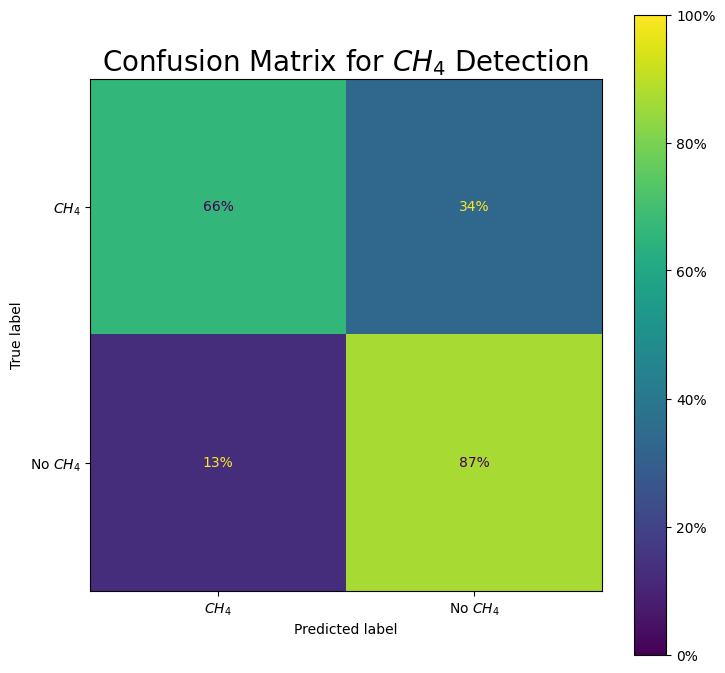

In [11]:
SNRall_probabilities = SNRall_rf.predict_proba(SNRall_X_test_encoded)[:, 1]

# Assign labels based on the adjusted threshold
threshold = 0.5
remove_warnings()
SNRall_y_pred = (SNRall_probabilities > threshold).astype(int)

# # Assign labels and scores to predictions
# SNRall_test["pred"] = SNRall_y_pred
# SNRall_test["score"] = SNRall_probabilities

# Print the confusion matrix and classification report
print(confusion_matrix(SNRall_y_test, SNRall_y_pred))
print(classification_report(SNRall_y_test, SNRall_y_pred))

plot_confusion_matrix(
    SNRall_y_test, SNRall_y_pred,
    labels=[1,0], display_labels=["$CH_4$", "No $CH_4$"],
    title="Confusion Matrix for $CH_4$ Detection "
)



## Evaluate the Model


Classification Report: 
              precision    recall  f1-score   support

           0       0.76      0.87      0.81      2960
           1       0.80      0.66      0.73      2400

    accuracy                           0.78      5360
   macro avg       0.78      0.77      0.77      5360
weighted avg       0.78      0.78      0.77      5360



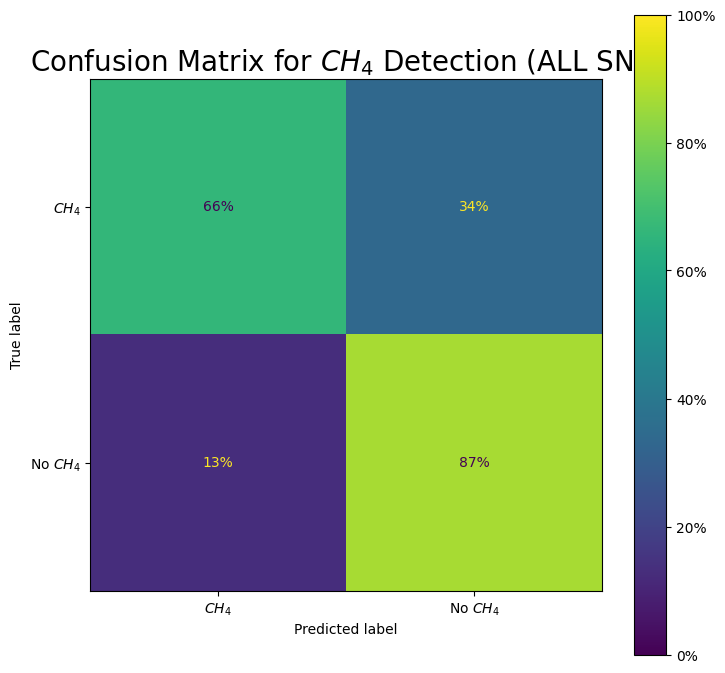

In [12]:
# Predict on the denoised test data
SNRall_y_pred_proba = SNRall_rf.predict_proba(SNRall_X_test_encoded)[:, 1]
SNRall_y_pred = (SNRall_y_pred_proba > threshold).astype(int)

print("Classification Report: ")
print(classification_report(SNRall_y_test, SNRall_y_pred))

plot_confusion_matrix(
    SNRall_y_test, SNRall_y_pred,
    labels=[1,0], display_labels=["$CH_4$", "No $CH_4$"],
    title="Confusion Matrix for $CH_4$ Detection (ALL SNR)"
)

# Add prediction back to the params dataframe for detailed analysis
SNRall_params_test["pred"] = SNRall_y_pred
SNRall_params_test["score"] = SNRall_y_pred_proba
SNRall_params_test["label"] = SNRall_y_test.values


## Detailed Validation by SNR and Mixing Ratio


In [13]:
print(SNRall_params_test.columns)


Index(['noise_std', 'n_repeat', 'f_spot', 'f_fac', 'Unnamed: 0', 'atm CH4',
       'atm H2O', 'atm O3', 'sma', 'seed', 'p_radius', 'p_mass', 'p_seed',
       'atm temperature', 'atm base_pressure', 'atm top_pressure',
       'atm fill_gas', 'atm seed', 'atm CO2', 's temperature', 's radius',
       's mass', 's seed', 'label', '5.297569', 'pred', 'score'],
      dtype='object')


In [15]:
print("\n--- Detailed Validation Analysis ---")

# Analysis performance across different SNR levels
for snr in SNRall_params_test['snr'].unique():
    subset = SNRall_params_test[SNRall_params_test['snr'] == snr]
    y_true = subset['label']
    y_pred = subset['pred']
    
    print(f"\nResults for SNR = {snr}:")
    print(classification_report(y_true, y_pred))
    plot_confusion_matrix(
        y_true, y_pred,
        labels=[1,0], display_labels=["$CH_4$", "No $CH_4$"],
        title=f"Confusion Matrix for $CH_4$ Detection (SNR = {snr})"
    )
    
# Analyze performance by CH4 mixing ratio for a specific SNR
snr_to_analyze = 1
print(f"\n--- Analysis by CH4 Mixing Ration for SNR = {snr_to_analyze} ---")

subset_snr = SNRall_params_test[SNRall_params_test['snr'] == snr_to_analyze]
f1_scores, recall_scores, precision_scores = [], [], []

for mr in sorted(subset_snr['atm CH4'].unique()):
    if mr > 0: # Only consider cases with CH4
        mr_subset = subset_snr[subset_snr['atm CH4'] == mr]
        y_true = mr_subset['label']
        y_pred = mr_subset['pred']
        
        f1_scores.append(f1_score(y_true, y_pred, zero_division=0))
        recall_scores.append(recall_score(y_true, y_pred, zero_division=0))
        precision_scores.append(precision_score(y_true, y_pred, zero_division=0))

# Plotting scores
plt.figure(figsize=(10, 6))
plt.plot(mix_ratios, f1_scores, marker='o', label="F1-Score")
plt.plot(mix_ratios, recall_scores, marker='s', label="Recall")
plt.plot(mix_ratios, precision_scores, marker='^', label="Precision")
plt.xscale("log")
plt.xlabel("CH4 Mixing Ratio (log scale)")
plt.ylabel("Score")
plt.title(f"Performance Metrics vs. CH4 Mixing Ratio (SNR={snr_to_analyze})")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()


--- Analysis by CH4 Mixing Ration for SNR = 1 ---


KeyError: 'snr'